In [2]:
import pickle 
import numpy as np
import matplotlib.pylab as pl
import matplotlib.gridspec as gridspec
import matplotlib.transforms as mtransforms
from matplotlib.ticker import ScalarFormatter

dsetot 3.571887181950409e-15 2.822155944408115e-15
dseyca 1.4019580027978927e-14 7.768493583878873e-15
dseyaa -4.286022370051542e-15 5.50732330393109e-15
dsexac 1.0912994828041135e-16 4.489657714282961e-15
dsexaa -2.818838861691816e-16 3.757718016677774e-15
dsez -6.144143977912594e-15 3.5035964865505276e-15
dseres -1.7301753256160314e-15 2.3504283870471904e-15
dsetot 2.046497374183941e-15 2.183599966826831e-15
dseyca 8.826936356543596e-15 4.8128077884593205e-15
dseyaa -2.6058760872220417e-15 3.731005728288947e-15
dsexac -1.533895598937908e-16 3.6377097111105277e-16
dsexaa -3.32391866655605e-16 2.2538469068437587e-15
dsez -3.480721811956282e-15 1.814331767410929e-15
dseres -8.511366549501557e-16 1.906369256024156e-15
dsetot 2.3312824509740664e-15 2.5385719704050262e-15
dseyca 9.73791111344994e-15 6.716686577377804e-15
dseyaa -4.641705652591495e-15 5.161379594974328e-15
dsexac 2.9296991512387426e-16 3.636343383555617e-15
dsexaa 1.0357946913387967e-16 3.606338091847322e-15
dsez -3.3376000

/tmp/ipykernel_302262/3442110394.py:160: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  ax1.annotate("50N - High intensity",xy=(0.56,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
/tmp/ipykernel_302262/3442110394.py:161: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  ax2.annotate("35N - High intensity",xy=(0.56,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
/tmp/ipykernel_302262/3442110394.py:162: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  ax3.annotate("50N - Low intensity",xy=(0.5725,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
/tmp/ipykernel_302262/34

Text(0.07, 0.5, 'Intensity (K)')

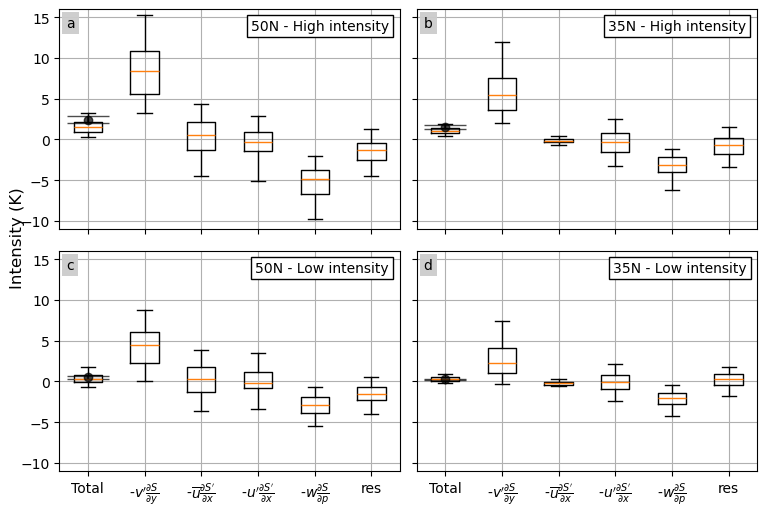

In [3]:
DSE2T50 = 0.0008716240163053267
DSE2T35 = 0.0009476501077694566
output_dir='/home/data/lab_project2/Steve/model_runs/aqua_planet/long-run/'

with open(output_dir+'dse_rey_HI_50', 'rb') as f:
    rey_HI_50 = pickle.load(f)

with open(output_dir+'dse_rey_HI_35', 'rb') as f:
    rey_HI_35 = pickle.load(f)

with open(output_dir+'dse_rey_LI_50', 'rb') as f:
    rey_LI_50 = pickle.load(f)

with open(output_dir+'dse_rey_LI_35', 'rb') as f:
    rey_LI_35 = pickle.load(f)
    
###########################################################################

def set_label(fig, ax, label):
    trans = mtransforms.ScaledTranslation(5/72, -5/72, fig.dpi_scale_trans)
    ax.text(0.0, 1.0, label, transform=ax.transAxes + trans,
            fontsize='medium', verticalalignment='top', fontfamily=None,
            bbox=dict(facecolor='0.8', edgecolor='none', pad=3.0, alpha=0.95))

formatter = ScalarFormatter()
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))

#fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
gs = gridspec.GridSpec(2, 2, hspace=0.1, wspace=0.05)
fig=pl.figure(figsize=(9,6))
ax1 = pl.subplot(gs[0, 0])
ax2 = pl.subplot(gs[0, 1]) 
ax3 = pl.subplot(gs[1, 0])
ax4 = pl.subplot(gs[1, 1])

######################### high intensity lat 50 ###########################

dse_master=rey_HI_50
x=[]
chk=[]
for d in ['dsetot','dseyca','dseyaa','dsexac','dsexaa','dsez','dseres']:
    chk.append( np.mean([np.mean(np.cumsum(np.insert(e, 0, 0))) for e in dse_master[d]])/1e18)
    x.append(([np.mean(np.cumsum(np.insert(e, 0, 0))) for e in dse_master[d]]))
    print(d, np.mean([np.mean(np.cumsum(np.insert(e, 0, 0))) for e in dse_master[d]])/1e18, np.std([e.cumsum().mean().item() for e in dse_master[d]])/1e18)

# combining dseyca and dseyaa
x[1] = (np.array(x[1])+np.array(x[2])).tolist()
x[0] = (np.array(x[0])+np.array(x[-1])).tolist()
x.pop(2)
x = [ (DSE2T50 * np.array(arr)).tolist() for arr in x ]
ax1.boxplot(x, showfliers=False, whis=(5,95))
intensity = dse_master['intensity']
lower, upper = np.percentile(intensity, [10, 90])
mean = np.mean(intensity)
ax1.errorbar([1], [mean], yerr=[[mean - lower],[upper - mean]],capsize=15,
    fmt="o", color="black", alpha= 0.7)

ax1.grid()
ax1.set_xticklabels([])
#ax1.yaxis.set_major_formatter(formatter)
ax1.autoscale(axis='y')
ax1.set_ylim(-11, 16)
ax1.yaxis.get_major_locator().set_params(prune='both')
set_label(fig, ax1, 'a')

####################### high intensity lat 35 #############################

dse_master=rey_HI_35
x=[]
chk=[]
for d in ['dsetot','dseyca','dseyaa','dsexac','dsexaa','dsez','dseres']:
    chk.append( np.mean([np.mean(np.cumsum(np.insert(e, 0, 0))) for e in dse_master[d]])/1e18)
    x.append(([np.mean(np.cumsum(np.insert(e, 0, 0))) for e in dse_master[d]]))
    print(d, np.mean([np.mean(np.cumsum(np.insert(e, 0, 0))) for e in dse_master[d]])/1e18, np.std([e.cumsum().mean().item() for e in dse_master[d]])/1e18)
#x = np.array(x)
x[1] = (np.array(x[1])+np.array(x[2])).tolist()
x[0] = (np.array(x[0])+np.array(x[-1])).tolist()
x.pop(2)
x = [ (DSE2T35 * np.array(arr)).tolist() for arr in x ]
ax2.boxplot(x, showfliers=False, whis=(5,95))
intensity = dse_master['intensity']
lower, upper = np.percentile(intensity, [10, 90])
mean = np.mean(intensity)
ax2.errorbar([1], [mean], yerr=[[mean - lower],[upper - mean]],capsize=15,
    fmt="o", color="black", alpha= 0.7)
ax2.grid()
ax2.set_xticklabels([])
#ax2.yaxis.set_major_formatter(formatter)
ax2.autoscale(axis='y')
ax2.set_ylim(-11, 16)
ax2.yaxis.get_major_locator().set_params(prune='both')
set_label(fig,ax2, 'b')
ax2.set_yticklabels([])

###################### low intensity lat 50 ###############################
dse_master=rey_LI_50
x=[]
chk=[]
for d in ['dsetot','dseyca','dseyaa','dsexac','dsexaa','dsez','dseres']:
    chk.append( np.mean([np.mean(np.cumsum(np.insert(e, 0, 0))) for e in dse_master[d]])/1e18)
    x.append(([np.mean(np.cumsum(np.insert(e, 0, 0))) for e in dse_master[d]]))
    print(d, np.mean([np.mean(np.cumsum(np.insert(e, 0, 0))) for e in dse_master[d]])/1e18, np.std([e.cumsum().mean().item() for e in dse_master[d]])/1e18)
#x = np.array(x)
x[1] = (np.array(x[1])+np.array(x[2])).tolist()
x[0] = (np.array(x[0])+np.array(x[-1])).tolist()
x.pop(2)
x = [ (DSE2T50 * np.array(arr)).tolist() for arr in x ]
ax3.boxplot(x, showfliers=False, whis=(5,95))
intensity = dse_master['intensity']
lower, upper = np.percentile(intensity, [10, 90])
mean = np.mean(intensity)
ax3.errorbar([1], [mean], yerr=[[mean - lower],[upper - mean]],capsize=15,
    fmt="o", color="black", alpha= 0.7)
ax3.grid()
ax3.autoscale(axis='y')
ax3.set_ylim(-11, 16)
ax3.yaxis.get_major_locator().set_params(prune='both')
#ax3.yaxis.set_major_formatter(formatter)
set_label(fig,ax3, 'c')
ax3.set_xticks([1, 2, 3, 4, 5, 6], ['Total', r'-$v^\prime\frac{\partial S}{\partial y}$',
                                r'-$\overline{u}\frac{\partial S^\prime}{\partial x}$',
                                r'-$u^\prime\frac{\partial S^\prime}{\partial x}$',
                                r'-$w\frac{\partial S}{\partial p}$',
                                'res'])

###################### low intensity lat 35 ###############################
dse_master=rey_LI_35
x=[]
chk=[]
for d in ['dsetot','dseyca','dseyaa','dsexac','dsexaa','dsez','dseres']:
    chk.append( np.mean([np.mean(np.cumsum(np.insert(e, 0, 0))) for e in dse_master[d]])/1e18)
    x.append(([np.mean(np.cumsum(np.insert(e, 0, 0))) for e in dse_master[d]]))
    print(d, np.mean([np.mean(np.cumsum(np.insert(e, 0, 0))) for e in dse_master[d]])/1e18, np.std([e.cumsum().mean().item() for e in dse_master[d]])/1e18)

x[1] = (np.array(x[1])+np.array(x[2])).tolist()
x[0] = (np.array(x[0])+np.array(x[-1])).tolist()
x.pop(2)
x = [ (DSE2T35 * np.array(arr)).tolist() for arr in x ]
ax4.boxplot(x, showfliers=False, whis=(5,95))
intensity = dse_master['intensity']
lower, upper = np.percentile(intensity, [10, 90])
mean = np.mean(intensity)
ax4.errorbar([1], [mean], yerr=[[mean - lower],[upper - mean]],capsize=15,
    fmt="o", color="black", alpha= 0.7)
ax4.grid()
#ax4.yaxis.set_major_formatter(formatter)
ax4.autoscale(axis='y')
ax4.set_ylim(-11, 16)
set_label(fig,ax4, 'd')
ax4.set_yticklabels([])
ax4.yaxis.get_major_locator().set_params(prune='both')
ax4.set_xticks([1, 2, 3, 4, 5, 6], ['Total', r'-$v^\prime\frac{\partial S}{\partial y}$',
                                r'-$\overline{u}\frac{\partial S^\prime}{\partial x}$',
                                r'-$u^\prime\frac{\partial S^\prime}{\partial x}$',
                                r'-$w\frac{\partial S}{\partial p}$',
                                'res'])


ax1.annotate("50N - High intensity",xy=(0.56,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
ax2.annotate("35N - High intensity",xy=(0.56,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
ax3.annotate("50N - Low intensity",xy=(0.5725,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
ax4.annotate("35N - Low intensity",xy=(0.575,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
fig.supylabel("Intensity (K)", fontsize=12, x=0.07)

#fig.savefig('3.pdf', bbox_inches='tight')
#fig.savefig('3.jpg',dpi=600, bbox_inches='tight')

In [20]:
mean = np.mean(rey_HI_35['intensity'])

In [21]:
mean

np.float64(1.4988979092616666)

In [2]:
output_dir='/home/data/lab_project2/Steve/model_runs/aqua_planet/long-run/'

with open(output_dir+'dse_rey_HI_50', 'rb') as f:
    rey_HI_50 = pickle.load(f)

In [4]:
len(rey_HI_50['index'])

121